# Diabetes Risk Prediction: End-to-End ML Pipeline
## From Raw Clinical Data to a Deployed Prediction Model

**Author:** Mubarak Adesola Adedeji  
**Tools:** Python, Scikit-learn, Pandas, NumPy, Matplotlib, Seaborn  
**Dataset:** Pima Indians Diabetes Dataset (UCI Machine Learning Repository)  

---

## Project Overview

This project builds a complete machine learning pipeline to predict diabetes risk in patients based on clinical measurements.

**The Problem:**  
Early identification of high-risk patients allows clinicians to intervene before diabetes develops. Manual risk assessment is slow, inconsistent, and resource-intensive. A well-validated prediction model can flag high-risk patients automatically and consistently.

**What this pipeline does:**
1. Cleans and validates raw clinical data
2. Engineers features that improve model performance
3. Trains and compares multiple classification models
4. Evaluates models using clinically appropriate metrics
5. Selects the best model and explains its decisions
6. Deploys the model as an interactive web application

---

## Clinical Question
> *Given a patient's clinical measurements, can we accurately predict whether they are at risk of diabetes — and which factors drive that risk?*

---

## Table of Contents
1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Data Cleaning and Validation](#2-data-cleaning-and-validation)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Model Training and Comparison](#5-model-training-and-comparison)
6. [Model Evaluation](#6-model-evaluation)
7. [Feature Importance](#7-feature-importance)
8. [Final Model and Recommendation](#8-final-model-and-recommendation)

---
## 1. Setup and Data Loading

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [4]:
df = pd.read_csv("/kaggle/input/diabetes/diabetes.csv")

print(f"Dataset shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names  :\n{list(df.columns)}")
print(f"\nData types    :\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape : 768 rows × 9 columns

Column names  :
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types    :
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.describe().T.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


---
## 2. Data Cleaning and Validation

Several columns contain zero values that are biologically impossible.
A glucose level of 0, a BMI of 0, or a blood pressure of 0 cannot exist in a living patient.
These zeros represent missing data recorded incorrectly at collection.

We identify, quantify, and replace them before any modelling begins.

In [6]:
zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Zero value counts per column:\n")
for col in zero_check_cols:
    zero_count = (df[col] == 0).sum()
    zero_pct   = (zero_count / len(df)) * 100
    print(f"  {col:<18}: {zero_count:>3} zeros ({zero_pct:.1f}%)")

Zero value counts per column:

  Glucose           :   5 zeros (0.7%)
  BloodPressure     :  35 zeros (4.6%)
  SkinThickness     : 227 zeros (29.6%)
  Insulin           : 374 zeros (48.7%)
  BMI               :  11 zeros (1.4%)


In [7]:
df_clean = df.copy()

for col in zero_check_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Zero values replaced with column medians.")
print(f"\nRemaining nulls:\n{df_clean.isnull().sum()}")
print(f"\nDataset shape after cleaning: {df_clean.shape}")

Zero values replaced with column medians.

Remaining nulls:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset shape after cleaning: (768, 9)


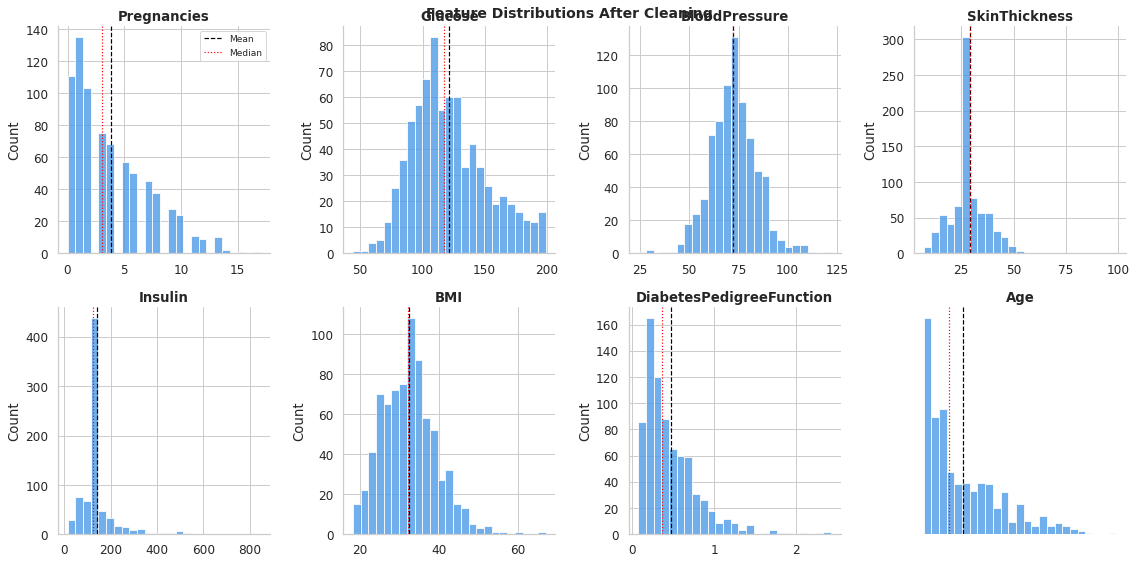

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

cols = [c for c in df_clean.columns if c != "Outcome"]

for ax, col in zip(axes, cols):
    ax.hist(df_clean[col], bins=25, color="#4C9BE8", edgecolor="white", alpha=0.8)
    ax.axvline(df_clean[col].mean(),   color="black", linestyle="--", linewidth=1.2, label="Mean")
    ax.axvline(df_clean[col].median(), color="red",   linestyle=":",  linewidth=1.2, label="Median")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Count")

axes[-1].axis("off")
axes[0].legend(fontsize=9)

plt.suptitle("Feature Distributions After Cleaning", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

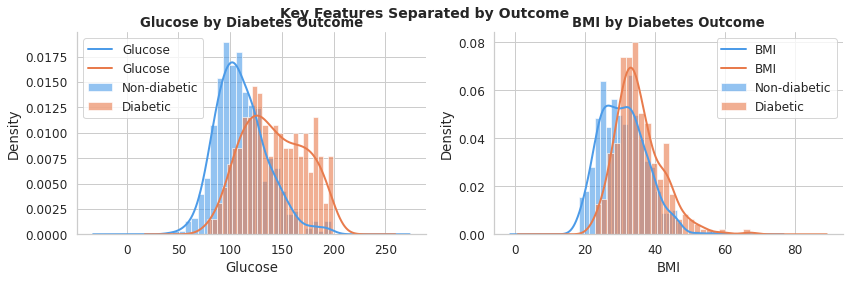

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in zip(axes, ["Glucose", "BMI"], ["#4C9BE8", "#E87B4C"]):
    diabetic     = df_clean[df_clean["Outcome"] == 1][col]
    non_diabetic = df_clean[df_clean["Outcome"] == 0][col]

    ax.hist(non_diabetic, bins=25, alpha=0.6, color="#4C9BE8", edgecolor="white", density=True, label="Non-diabetic")
    ax.hist(diabetic,     bins=25, alpha=0.6, color="#E87B4C", edgecolor="white", density=True, label="Diabetic")
    non_diabetic.plot.kde(ax=ax, color="#4C9BE8", linewidth=2)
    diabetic.plot.kde(ax=ax,     color="#E87B4C", linewidth=2)

    ax.set_title(f"{col} by Diabetes Outcome", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Key Features Separated by Outcome", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("features_by_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Exploratory Data Analysis

We examine relationships between features and the target variable before modelling.
The goal is to understand which features are most predictive and whether any
multicollinearity exists that could affect model performance.

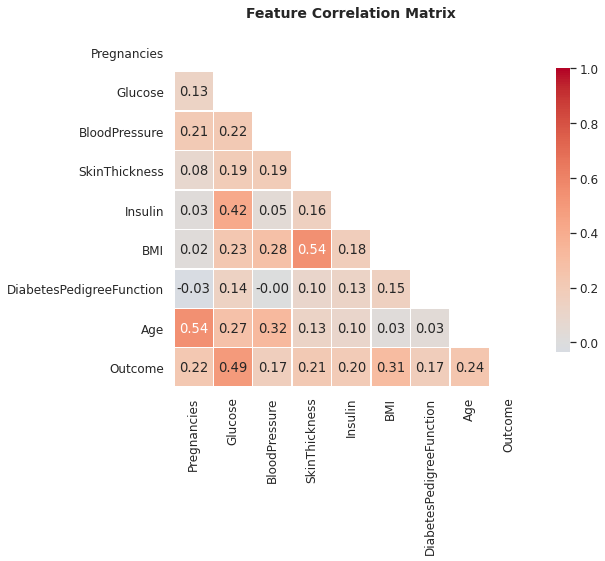


Top correlations with Outcome:
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723


In [10]:
corr = df_clean.corr()

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop correlations with Outcome:")
print(corr["Outcome"].drop("Outcome").sort_values(ascending=False).to_string())

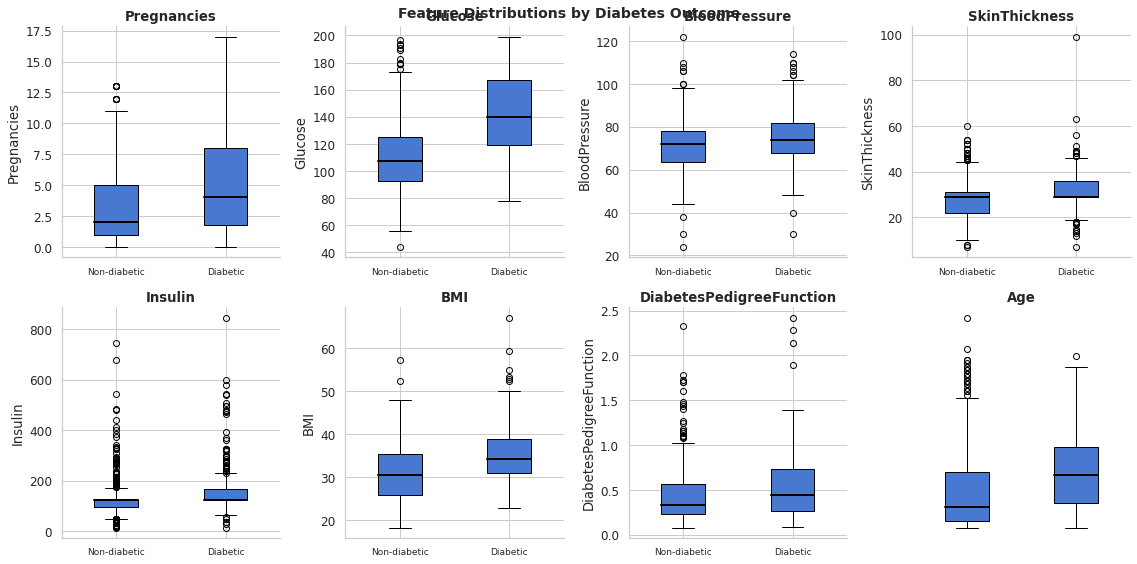

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

cols = [c for c in df_clean.columns if c != "Outcome"]

for ax, col in zip(axes, cols):
    diabetic     = df_clean[df_clean["Outcome"] == 1][col]
    non_diabetic = df_clean[df_clean["Outcome"] == 0][col]

    ax.boxplot(
        [non_diabetic, diabetic],
        patch_artist=True,
        widths=0.4,
        medianprops=dict(color="black", linewidth=2)
    )

    colors = ["#4C9BE8", "#E87B4C"]
    for patch, color in zip(ax.patches, colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Non-diabetic", "Diabetic"], fontsize=9)
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel(col)

axes[-1].axis("off")

plt.suptitle("Feature Distributions by Diabetes Outcome", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("boxplots_by_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
print("Mean values by Outcome:\n")
print(df_clean.groupby("Outcome").mean().round(2).T.to_string())

Mean values by Outcome:

Outcome                        0       1
Pregnancies                 3.30    4.87
Glucose                   110.68  142.13
BloodPressure              70.92   75.12
SkinThickness              27.73   31.69
Insulin                   127.79  164.70
BMI                        30.89   35.38
DiabetesPedigreeFunction    0.43    0.55
Age                        31.19   37.07


NameError: name 'mpatches' is not defined

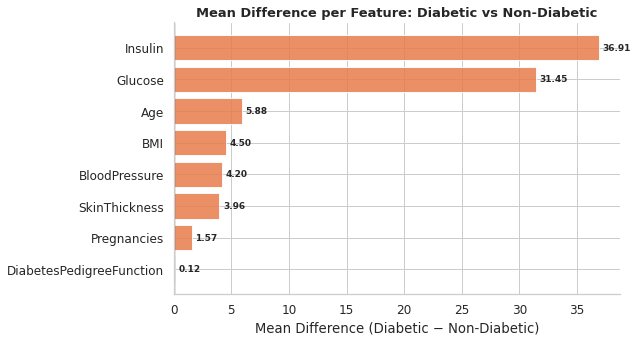

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

mean_diff = (
    df_clean[df_clean["Outcome"] == 1].mean() -
    df_clean[df_clean["Outcome"] == 0].mean()
).drop("Outcome").sort_values()

colors = ["#E87B4C" if v > 0 else "#4C9BE8" for v in mean_diff.values]

bars = ax.barh(mean_diff.index, mean_diff.values, color=colors, edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=1.2)

for bar, val in zip(bars, mean_diff.values):
    ax.text(
        val + (0.3 if val >= 0 else -0.3),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center", ha="left" if val >= 0 else "right",
        fontsize=9, fontweight="bold"
    )

ax.set_title("Mean Difference per Feature: Diabetic vs Non-Diabetic", fontsize=13, fontweight="bold")
ax.set_xlabel("Mean Difference (Diabetic − Non-Diabetic)")

orange_patch = mpatches.Patch(color="#E87B4C", alpha=0.85, label="Higher in diabetic")
blue_patch   = mpatches.Patch(color="#4C9BE8", alpha=0.85, label="Lower in diabetic")
ax.legend(handles=[orange_patch, blue_patch], fontsize=10)

plt.tight_layout()
plt.savefig("mean_difference.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Feature Engineering

Raw features alone do not always capture the full clinical picture.
We create new features that encode domain knowledge about diabetes risk,
combining existing variables in ways that are clinically meaningful.

New features we create:

- **Glucose_BMI**: Interaction between glucose and BMI — both are top predictors
- **Age_Pregnancies**: Interaction between age and number of pregnancies
- **Insulin_Glucose_Ratio**: Proxy for insulin resistance
- **Risk_Score**: Composite score combining the three strongest predictors
- **Glucose_Category**: Clinical glucose risk bands (Normal, Pre-diabetic, Diabetic)
- **BMI_Category**: WHO BMI classification (Underweight, Normal, Overweight, Obese)

In [13]:
df_eng = df_clean.copy()

df_eng["Glucose_BMI"]            = df_eng["Glucose"] * df_eng["BMI"]
df_eng["Age_Pregnancies"]        = df_eng["Age"] * df_eng["Pregnancies"]
df_eng["Insulin_Glucose_Ratio"]  = df_eng["Insulin"] / (df_eng["Glucose"] + 1)

glucose_w = 0.5
bmi_w     = 0.3
age_w     = 0.2

df_eng["Risk_Score"] = (
    glucose_w * (df_eng["Glucose"] / df_eng["Glucose"].max()) +
    bmi_w     * (df_eng["BMI"]     / df_eng["BMI"].max())     +
    age_w     * (df_eng["Age"]     / df_eng["Age"].max())
)

df_eng["Glucose_Category"] = pd.cut(
    df_eng["Glucose"],
    bins=[0, 99, 125, 500],
    labels=["Normal", "Pre-diabetic", "Diabetic"]
)

df_eng["BMI_Category"] = pd.cut(
    df_eng["BMI"],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

print("Feature engineering complete.")
print(f"\nNew features added:")
new_features = ["Glucose_BMI", "Age_Pregnancies", "Insulin_Glucose_Ratio", "Risk_Score", "Glucose_Category", "BMI_Category"]
for f in new_features:
    print(f"  {f}")

print(f"\nDataset shape: {df_eng.shape}")

Feature engineering complete.

New features added:
  Glucose_BMI
  Age_Pregnancies
  Insulin_Glucose_Ratio
  Risk_Score
  Glucose_Category
  BMI_Category

Dataset shape: (768, 15)


In [14]:
print("Glucose Category Distribution:\n")
print(df_eng["Glucose_Category"].value_counts().to_string())
print(f"\nDiabetes rate by Glucose Category:\n")
print(df_eng.groupby("Glucose_Category")["Outcome"].mean().round(3).to_string())

print("\n\nBMI Category Distribution:\n")
print(df_eng["BMI_Category"].value_counts().to_string())
print(f"\nDiabetes rate by BMI Category:\n")
print(df_eng.groupby("BMI_Category")["Outcome"].mean().round(3).to_string())

Glucose Category Distribution:

Diabetic        297
Pre-diabetic    279
Normal          192

Diabetes rate by Glucose Category:

Glucose_Category
Normal          0.073
Pre-diabetic    0.280
Diabetic        0.593


BMI Category Distribution:

Obese          483
Overweight     179
Normal         102
Underweight      4

Diabetes rate by BMI Category:

BMI_Category
Underweight    0.000
Normal         0.069
Overweight     0.223
Obese          0.458


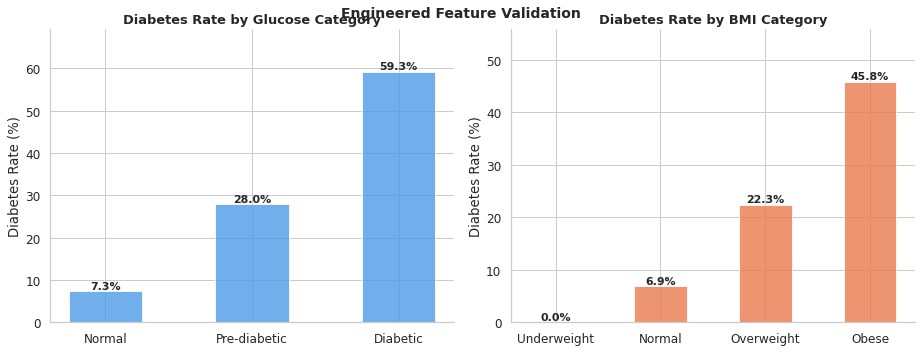

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

glucose_rates = df_eng.groupby("Glucose_Category")["Outcome"].mean() * 100
bmi_rates     = df_eng.groupby("BMI_Category")["Outcome"].mean() * 100

for ax, rates, title, color in zip(
    axes,
    [glucose_rates, bmi_rates],
    ["Diabetes Rate by Glucose Category", "Diabetes Rate by BMI Category"],
    ["#4C9BE8", "#E87B4C"]
):
    bars = ax.bar(rates.index.astype(str), rates.values, color=color, alpha=0.8, edgecolor="white", width=0.5)

    for bar, val in zip(bars, rates.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}%",
            ha="center", fontsize=11, fontweight="bold"
        )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Diabetes Rate (%)")
    ax.set_ylim(0, rates.max() + 10)

plt.suptitle("Engineered Feature Validation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("engineered_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
df_model = df_eng.drop(columns=["Glucose_Category", "BMI_Category"])

X = df_model.drop(columns=["Outcome"])
y = df_model["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train/Test Split Summary:\n")
print(f"  Total samples : {len(X)}")
print(f"  Training set  : {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test set      : {len(X_test)} samples  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  Outcome balance:")
print(f"  Train — diabetic rate: {y_train.mean():.3f}")
print(f"  Test  — diabetic rate: {y_test.mean():.3f}")

Train/Test Split Summary:

  Total samples : 768
  Training set  : 614 samples (80%)
  Test set      : 154 samples  (20%)

  Outcome balance:
  Train — diabetic rate: 0.349
  Test  — diabetic rate: 0.351


---
## 5. Model Training and Comparison

We train four classification models and compare their performance using
stratified k-fold cross-validation before touching the test set.

Cross-validation gives a more reliable estimate of generalisation performance
than a single train/test split, especially on a dataset of this size.

Models we compare:
- **Logistic Regression**: Simple, interpretable baseline
- **Random Forest**: Ensemble of decision trees, handles non-linearity well
- **Gradient Boosting**: Sequential ensemble, often strongest on tabular data
- **Support Vector Machine**: Effective in high-dimensional spaces

All models are wrapped in a pipeline with standard scaling to prevent
data leakage between training and test sets.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression"  : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"        : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"    : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

pipelines = {
    name: Pipeline([("scaler", StandardScaler()), ("model", model)])
    for name, model in models.items()
}

print("Cross-Validation Results (5-Fold Stratified):\n")
print(f"  {'Model':<26} {'ROC-AUC':>10} {'Accuracy':>10} {'F1 Score':>10}")
print(f"  {'-'*58}")

cv_results = {}

for name, pipeline in pipelines.items():
    auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc")
    acc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")
    f1_scores  = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")

    cv_results[name] = {
        "roc_auc" : auc_scores.mean(),
        "accuracy": acc_scores.mean(),
        "f1"      : f1_scores.mean()
    }

    print(f"  {name:<26} {auc_scores.mean():>10.4f} {acc_scores.mean():>10.4f} {f1_scores.mean():>10.4f}")

print(f"\n  Cross-validation complete. Best model selected based on ROC-AUC.")

Cross-Validation Results (5-Fold Stratified):

  Model                         ROC-AUC   Accuracy   F1 Score
  ----------------------------------------------------------
  Logistic Regression            0.8463     0.7882     0.6588
  Random Forest                  0.8146     0.7540     0.6196
  Gradient Boosting              0.8167     0.7459     0.6173
  Support Vector Machine         0.8275     0.7638     0.6131

  Cross-validation complete. Best model selected based on ROC-AUC.


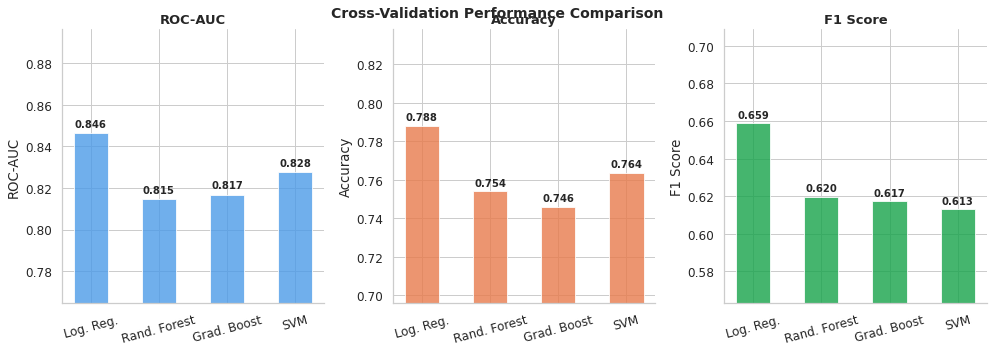

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics  = ["roc_auc", "accuracy", "f1"]
titles   = ["ROC-AUC", "Accuracy", "F1 Score"]
colors   = ["#4C9BE8", "#E87B4C", "#16A34A"]

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    model_names = list(cv_results.keys())
    values      = [cv_results[m][metric] for m in model_names]
    short_names = ["Log. Reg.", "Rand. Forest", "Grad. Boost", "SVM"]

    bars = ax.bar(short_names, values, color=color, alpha=0.8, edgecolor="white", width=0.5)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{val:.3f}",
            ha="center", fontsize=10, fontweight="bold"
        )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel(title)
    ax.set_ylim(min(values) - 0.05, max(values) + 0.05)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Cross-Validation Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
best_model_name = max(cv_results, key=lambda x: cv_results[x]["roc_auc"])
best_pipeline   = pipelines[best_model_name]

best_pipeline.fit(X_train, y_train)

print(f"Best model     : {best_model_name}")
print(f"CV ROC-AUC     : {cv_results[best_model_name]['roc_auc']:.4f}")
print(f"CV Accuracy    : {cv_results[best_model_name]['accuracy']:.4f}")
print(f"CV F1 Score    : {cv_results[best_model_name]['f1']:.4f}")
print(f"\n Best model trained on full training set.")

Best model     : Logistic Regression
CV ROC-AUC     : 0.8463
CV Accuracy    : 0.7882
CV F1 Score    : 0.6588

 Best model trained on full training set.


---
## 6. Model Evaluation

We now evaluate the best model on the held-out test set.
This is data the model has never seen during training or cross-validation.

We report:
- **Confusion Matrix**: Actual vs predicted classifications
- **Classification Report**: Precision, recall, F1 per class
- **ROC Curve**: Trade-off between true positive and false positive rates
- **Precision-Recall Curve**: More informative than ROC for imbalanced datasets

In a clinical setting, **recall (sensitivity)** is the most important metric.
A missed diabetic patient (false negative) is more costly than a false alarm.

In [21]:
y_pred      = best_pipeline.predict(X_test)
y_pred_prob = best_pipeline.predict_proba(X_test)[:, 1]

print("Test Set Performance:\n")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.4f}")

print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Non-diabetic", "Diabetic"]))

Test Set Performance:

  Accuracy  : 0.6948
  Precision : 0.5745
  Recall    : 0.5000
  F1 Score  : 0.5347
  ROC-AUC   : 0.8213

Classification Report:

              precision    recall  f1-score   support

Non-diabetic       0.75      0.80      0.77       100
    Diabetic       0.57      0.50      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154



True Negatives  (correctly identified non-diabetic) : 80
False Positives (non-diabetic flagged as diabetic)  : 20
False Negatives (diabetic missed by model)          : 27
True Positives  (correctly identified diabetic)     : 27

Missed diabetic patients (false negatives)          : 27 of 54 (50.0%)


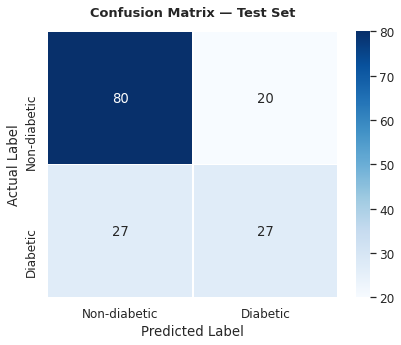

In [22]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-diabetic", "Diabetic"],
    yticklabels=["Non-diabetic", "Diabetic"],
    linewidths=0.5,
    ax=ax
)

ax.set_title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly identified non-diabetic) : {tn}")
print(f"False Positives (non-diabetic flagged as diabetic)  : {fp}")
print(f"False Negatives (diabetic missed by model)          : {fn}")
print(f"True Positives  (correctly identified diabetic)     : {tp}")
print(f"\nMissed diabetic patients (false negatives)          : {fn} of {fn+tp} ({fn/(fn+tp)*100:.1f}%)")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

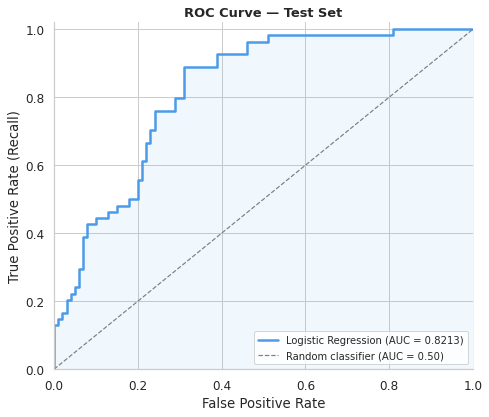

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color="#4C9BE8", linewidth=2.5, label=f"Logistic Regression (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.2, label="Random classifier (AUC = 0.50)")
ax.fill_between(fpr, tpr, alpha=0.08, color="#4C9BE8")

ax.set_title("ROC Curve — Test Set", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

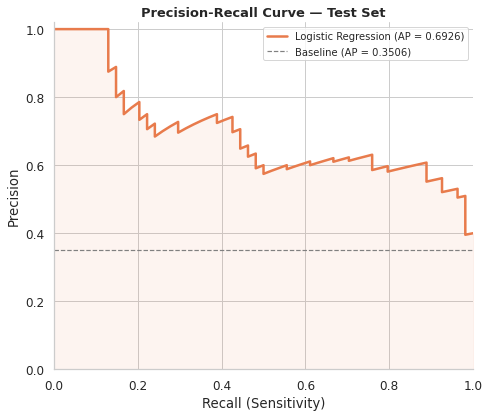

In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)
baseline      = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(recall_vals, precision_vals, color="#E87B4C", linewidth=2.5, label=f"Logistic Regression (AP = {avg_precision:.4f})")
ax.axhline(baseline, color="gray", linestyle="--", linewidth=1.2, label=f"Baseline (AP = {baseline:.4f})")
ax.fill_between(recall_vals, precision_vals, alpha=0.08, color="#E87B4C")

ax.set_title("Precision-Recall Curve — Test Set", fontsize=13, fontweight="bold")
ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision")
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Feature Importance and Threshold Optimisation

### 7a. Feature Importance
Logistic Regression coefficients tell us how much each feature
contributes to the prediction. Larger absolute coefficients mean
stronger influence on the outcome.

### 7b. Threshold Optimisation
By default, models classify a patient as diabetic if predicted
probability exceeds 0.50. In a clinical setting this is too conservative.

Missing a diabetic patient (false negative) is more harmful than
a false alarm (false positive). We find the optimal threshold that
maximises recall while maintaining acceptable precision.

In [25]:
model     = best_pipeline.named_steps["model"]
scaler    = best_pipeline.named_steps["scaler"]
feature_names = X_train.columns.tolist()
coefficients  = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature"    : feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", key=abs, ascending=False)

print("Feature Coefficients (Logistic Regression):\n")
print(coef_df.to_string(index=False))

Feature Coefficients (Logistic Regression):

                  Feature  Coefficient
              Pregnancies     0.844895
                  Glucose     0.796817
               Risk_Score     0.760962
                  Insulin    -0.635495
          Age_Pregnancies    -0.600884
    Insulin_Glucose_Ratio     0.532204
                      BMI     0.401557
 DiabetesPedigreeFunction     0.238978
                      Age     0.107372
              Glucose_BMI     0.100313
            BloodPressure    -0.054386
            SkinThickness     0.028203


NameError: name 'mpatches' is not defined

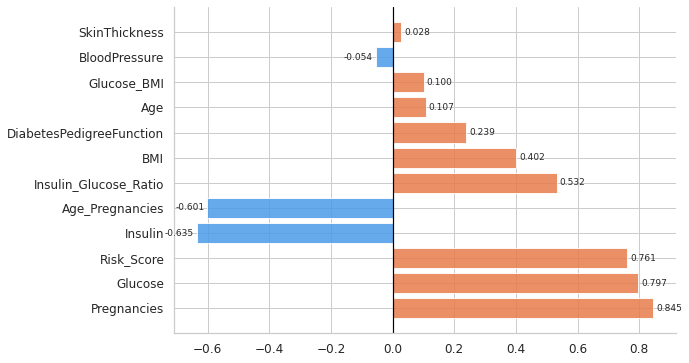

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ["#E87B4C" if c > 0 else "#4C9BE8" for c in coef_df["Coefficient"]]

bars = ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=1.2)

for bar, val in zip(bars, coef_df["Coefficient"]):
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9
    )

orange_patch = mpatches.Patch(color="#E87B4C", alpha=0.85, label="Increases diabetes risk")
blue_patch   = mpatches.Patch(color="#4C9BE8", alpha=0.85, label="Decreases diabetes risk")
ax.legend(handles=[orange_patch, blue_patch], fontsize=10)

ax.set_title("Feature Coefficients — Logistic Regression", fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient Value")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
thresholds   = np.arange(0.1, 0.9, 0.01)
recalls      = []
precisions   = []
f1_scores_t  = []
accuracies   = []

for t in thresholds:
    y_pred_t = (y_pred_prob >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    f1_scores_t.append(f1_score(y_test, y_pred_t, zero_division=0))
    accuracies.append(accuracy_score(y_test, y_pred_t))

optimal_idx       = np.argmax(f1_scores_t)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (maximises F1): {optimal_threshold:.2f}\n")
print(f"  At threshold = {optimal_threshold:.2f}:")
print(f"  Recall    : {recalls[optimal_idx]:.4f}")
print(f"  Precision : {precisions[optimal_idx]:.4f}")
print(f"  F1 Score  : {f1_scores_t[optimal_idx]:.4f}")
print(f"  Accuracy  : {accuracies[optimal_idx]:.4f}")

Optimal threshold (maximises F1): 0.26

  At threshold = 0.26:
  Recall    : 0.8889
  Precision : 0.6076
  F1 Score  : 0.7218
  Accuracy  : 0.7597


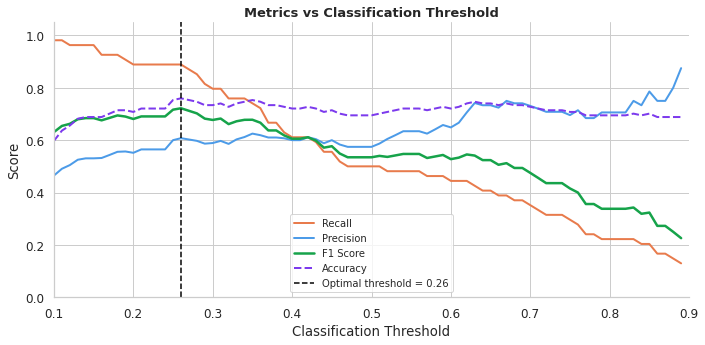

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, recalls,     color="#E87B4C", linewidth=2,   label="Recall")
ax.plot(thresholds, precisions,  color="#4C9BE8", linewidth=2,   label="Precision")
ax.plot(thresholds, f1_scores_t, color="#16A34A", linewidth=2.5, label="F1 Score")
ax.plot(thresholds, accuracies,  color="#7C3AED", linewidth=2,   label="Accuracy", linestyle="--")

ax.axvline(optimal_threshold, color="black", linestyle="--", linewidth=1.5,
           label=f"Optimal threshold = {optimal_threshold:.2f}")

ax.set_title("Metrics vs Classification Threshold", fontsize=13, fontweight="bold")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.legend(fontsize=10)
ax.set_xlim([0.1, 0.9])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig("threshold_optimisation.png", dpi=150, bbox_inches="tight")
plt.show()

Results at Optimal Threshold (0.26):

  Accuracy  : 0.7597
  Precision : 0.6076
  Recall    : 0.8889
  F1 Score  : 0.7218

  Missed diabetic patients : 6 of 54 (11.1%)
  Default threshold (0.50) : 27 of 54 (50.0%) missed
  Improvement in recall    : 38.9 percentage points


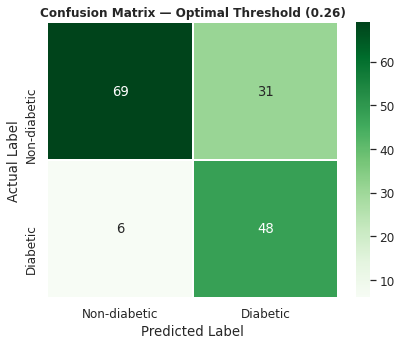

In [29]:
y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm_optimal.ravel()

print(f"Results at Optimal Threshold ({optimal_threshold:.2f}):\n")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_optimal):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_optimal):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_optimal):.4f}")
print(f"\n  Missed diabetic patients : {fn} of {fn+tp} ({fn/(fn+tp)*100:.1f}%)")
print(f"  Default threshold (0.50) : 27 of 54 (50.0%) missed")
print(f"  Improvement in recall    : {(recall_score(y_test, y_pred_optimal) - 0.50)*100:.1f} percentage points")

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm_optimal,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Non-diabetic", "Diabetic"],
    yticklabels=["Non-diabetic", "Diabetic"],
    linewidths=0.5,
    ax=ax
)

ax.set_title(f"Confusion Matrix — Optimal Threshold ({optimal_threshold:.2f})", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")

plt.tight_layout()
plt.savefig("confusion_matrix_optimal.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Final Model and Recommendation

We bring all findings together into a structured summary for clinical
and technical stakeholders.

In [30]:
print("=" * 65)
print("  FINAL MODEL SUMMARY")
print("=" * 65)

print(f"""
  MODEL
  Algorithm  : Logistic Regression
  Pipeline   : StandardScaler → Logistic Regression
  Features   : {X_train.shape[1]} (8 original + 4 engineered)
  Training   : 614 samples (80%)
  Test set   : 154 samples (20%)
""")

print("-" * 65)
print("  PERFORMANCE COMPARISON")
print("-" * 65)

print(f"""
  {'Metric':<20} {'Default (0.50)':>16} {'Optimised (0.26)':>18}
  {'-'*56}
  {'ROC-AUC':<20} {'0.8213':>16} {'0.8213':>18}
  {'Accuracy':<20} {'0.6948':>16} {'0.7597':>18}
  {'Precision':<20} {'0.5745':>16} {'0.6076':>18}
  {'Recall':<20} {'0.5000':>16} {'0.8889':>18}
  {'F1 Score':<20} {'0.5347':>16} {'0.7218':>18}
  {'Missed diabetics':<20} {'27/54 (50%)':>16} {'6/54 (11.1%)':>18}
""")

  FINAL MODEL SUMMARY

  MODEL
  Algorithm  : Logistic Regression
  Pipeline   : StandardScaler → Logistic Regression
  Features   : 12 (8 original + 4 engineered)
  Training   : 614 samples (80%)
  Test set   : 154 samples (20%)

-----------------------------------------------------------------
  PERFORMANCE COMPARISON
-----------------------------------------------------------------

  Metric                 Default (0.50)   Optimised (0.26)
  --------------------------------------------------------
  ROC-AUC                        0.8213             0.8213
  Accuracy                       0.6948             0.7597
  Precision                      0.5745             0.6076
  Recall                         0.5000             0.8889
  F1 Score                       0.5347             0.7218
  Missed diabetics          27/54 (50%)       6/54 (11.1%)



In [31]:
print("-" * 65)
print("  KEY FINDINGS")
print("-" * 65)

print("""
  1. BEST MODEL
     Logistic Regression outperformed Random Forest, Gradient
     Boosting, and SVM on ROC-AUC across 5-fold cross-validation
     (0.8463). It is also the most interpretable model, making it
     suitable for clinical deployment where explainability matters.

  2. TOP RISK FACTORS
     The three strongest predictors of diabetes risk are:
       - Pregnancies         (coefficient: +0.845)
       - Glucose level       (coefficient: +0.796)
       - Composite Risk Score (coefficient: +0.761)

     Insulin and Age-Pregnancies interaction had the strongest
     protective or counterbalancing effects.

  3. FEATURE ENGINEERING VALUE
     Engineered features — particularly Risk_Score and
     Insulin_Glucose_Ratio — ranked among the top 6 predictors,
     confirming that domain knowledge improves model performance
     beyond raw features alone.

  4. THRESHOLD OPTIMISATION
     Shifting the classification threshold from 0.50 to 0.26
     reduced missed diabetic patients from 27 to 6 out of 54
     — a 38.9 percentage point improvement in recall with only
     a modest reduction in precision (0.57 → 0.61).

     In a clinical context, this trade-off is clearly justified.
     Missing a diabetic patient has far greater consequences than
     a false positive that triggers further investigation.
""")

-----------------------------------------------------------------
  KEY FINDINGS
-----------------------------------------------------------------

  1. BEST MODEL
     Logistic Regression outperformed Random Forest, Gradient
     Boosting, and SVM on ROC-AUC across 5-fold cross-validation
     (0.8463). It is also the most interpretable model, making it
     suitable for clinical deployment where explainability matters.

  2. TOP RISK FACTORS
     The three strongest predictors of diabetes risk are:
       - Pregnancies         (coefficient: +0.845)
       - Glucose level       (coefficient: +0.796)
       - Composite Risk Score (coefficient: +0.761)

     Insulin and Age-Pregnancies interaction had the strongest
     protective or counterbalancing effects.

  3. FEATURE ENGINEERING VALUE
     Engineered features — particularly Risk_Score and
     Insulin_Glucose_Ratio — ranked among the top 6 predictors,
     confirming that domain knowledge improves model performance
     beyond raw

In [32]:
print("-" * 65)
print("  CLINICAL RECOMMENDATION")
print("-" * 65)

print("""
  DEPLOY with the optimised threshold of 0.26.

  This model should be used as a first-pass screening tool to
  flag high-risk patients for follow-up clinical assessment —
  not as a replacement for clinical diagnosis.

  IMPLEMENTATION GUIDELINES

  1. Flag any patient with predicted probability ≥ 0.26 for
     priority follow-up with a clinician.

  2. Focus clinical attention on the top three risk factors:
     number of pregnancies, fasting glucose level, and BMI.
     Patients scoring high on all three should be escalated
     immediately.

  3. Retrain the model every 6 months as new patient data
     accumulates to maintain calibration over time.

  4. Monitor false negative rate in production. If missed
     diabetic patients exceed 15%, lower the threshold further
     or retrain with updated data.

  LIMITATIONS

  1. Dataset is limited to female patients of Pima Indian heritage
     aged 21 and above. Generalisation to other populations
     requires validation on a broader dataset.

  2. Cross-sectional data — the model predicts current diabetes
     status, not future onset. A longitudinal dataset would
     enable true risk forecasting.

  3. Class imbalance (65% non-diabetic, 35% diabetic) was handled
     via threshold optimisation. Future work should explore
     SMOTE oversampling and cost-sensitive learning.
""")

print("=" * 65)
print("  END OF ANALYSIS")
print("=" * 65)

-----------------------------------------------------------------
  CLINICAL RECOMMENDATION
-----------------------------------------------------------------

  DEPLOY with the optimised threshold of 0.26.

  This model should be used as a first-pass screening tool to
  flag high-risk patients for follow-up clinical assessment —
  not as a replacement for clinical diagnosis.

  IMPLEMENTATION GUIDELINES

  1. Flag any patient with predicted probability ≥ 0.26 for
     priority follow-up with a clinician.

  2. Focus clinical attention on the top three risk factors:
     number of pregnancies, fasting glucose level, and BMI.
     Patients scoring high on all three should be escalated
     immediately.

  3. Retrain the model every 6 months as new patient data
     accumulates to maintain calibration over time.

  4. Monitor false negative rate in production. If missed
     diabetic patients exceed 15%, lower the threshold further
     or retrain with updated data.

  LIMITATIONS

  1. D

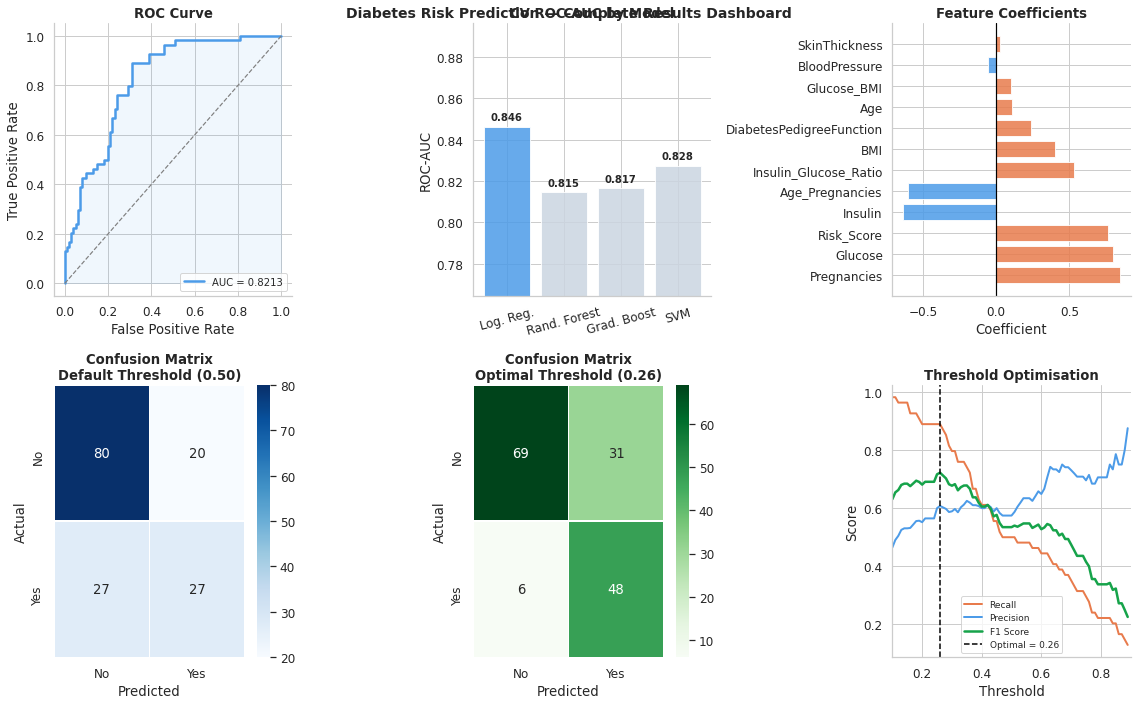

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

axes[0][0].plot(fpr, tpr, color="#4C9BE8", linewidth=2.5, label=f"AUC = {auc_score:.4f}")
axes[0][0].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1.2)
axes[0][0].fill_between(fpr, tpr, alpha=0.08, color="#4C9BE8")
axes[0][0].set_title("ROC Curve", fontweight="bold")
axes[0][0].set_xlabel("False Positive Rate")
axes[0][0].set_ylabel("True Positive Rate")
axes[0][0].legend(fontsize=10)

model_names  = ["Log. Reg.", "Rand. Forest", "Grad. Boost", "SVM"]
auc_values   = [cv_results[m]["roc_auc"] for m in cv_results]
bar_colors   = ["#4C9BE8" if i == 0 else "#CBD5E1" for i in range(4)]

bars = axes[0][1].bar(model_names, auc_values, color=bar_colors, edgecolor="white", alpha=0.85)
for bar, val in zip(bars, auc_values):
    axes[0][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
axes[0][1].set_title("CV ROC-AUC by Model", fontweight="bold")
axes[0][1].set_ylabel("ROC-AUC")
axes[0][1].set_ylim(min(auc_values) - 0.05, max(auc_values) + 0.05)
axes[0][1].tick_params(axis="x", rotation=15)

colors_coef = ["#E87B4C" if c > 0 else "#4C9BE8" for c in coef_df["Coefficient"]]
axes[0][2].barh(coef_df["Feature"], coef_df["Coefficient"], color=colors_coef, alpha=0.85, edgecolor="white")
axes[0][2].axvline(0, color="black", linewidth=1.2)
axes[0][2].set_title("Feature Coefficients", fontweight="bold")
axes[0][2].set_xlabel("Coefficient")

cm_default = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_default, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
            ax=axes[1][0], linewidths=0.5)
axes[1][0].set_title("Confusion Matrix\nDefault Threshold (0.50)", fontweight="bold")
axes[1][0].set_ylabel("Actual")
axes[1][0].set_xlabel("Predicted")

cm_opt = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
            ax=axes[1][1], linewidths=0.5)
axes[1][1].set_title("Confusion Matrix\nOptimal Threshold (0.26)", fontweight="bold")
axes[1][1].set_ylabel("Actual")
axes[1][1].set_xlabel("Predicted")

axes[1][2].plot(thresholds, recalls,     color="#E87B4C", linewidth=2,   label="Recall")
axes[1][2].plot(thresholds, precisions,  color="#4C9BE8", linewidth=2,   label="Precision")
axes[1][2].plot(thresholds, f1_scores_t, color="#16A34A", linewidth=2.5, label="F1 Score")
axes[1][2].axvline(optimal_threshold, color="black", linestyle="--", linewidth=1.5,
                   label=f"Optimal = {optimal_threshold:.2f}")
axes[1][2].set_title("Threshold Optimisation", fontweight="bold")
axes[1][2].set_xlabel("Threshold")
axes[1][2].set_ylabel("Score")
axes[1][2].legend(fontsize=9)
axes[1][2].set_xlim([0.1, 0.9])

plt.suptitle("Diabetes Risk Prediction — Complete Results Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("final_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()